# SleepWise - Phase 2 Model Implementation and Evaluation

This notebook implements the Phase 2 requirements for the SleepWise project:
- End-to-end model development from scratch
- Data preprocessing and label creation
- Multiple classification models
- Hyperparameter tuning
- Evaluation on **test data**
- Metrics: **Accuracy, Precision, Recall, F1-Score, Confusion Matrix**
- Cross-validation and feature importance analysis

## How to use this notebook
1. Place the Kaggle dataset CSV in the same folder as this notebook, or update the `DATA_PATH` below.
2. Run all cells in order.
3. Export the finished notebook and rename it with your **group number** before submission.

Recommended final filename:
`GROUP_NUMBER.ipynb`

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

## 1. Load the dataset

This notebook is built for the Kaggle Sleep Efficiency dataset mentioned in the project plan.
If your CSV has a different name, just update `DATA_PATH`.

In [5]:
# Update this if your file has a different name
DATA_PATH = "Sleep_Efficiency.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (452, 15)


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


## 2. Initial data inspection

In [6]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes)
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['ID', 'Age', 'Gender', 'Bedtime', 'Wakeup time', 'Sleep duration', 'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Smoking status', 'Exercise frequency']

Data types:


,0
ID,int64
Age,int64
Gender,object
Bedtime,object
Wakeup time,object
Sleep duration,float64
Sleep efficiency,float64
REM sleep percentage,int64
Deep sleep percentage,int64
Light sleep percentage,int64



Missing values:


,0
Caffeine consumption,25
Awakenings,20
Alcohol consumption,14
Exercise frequency,6
ID,0
Age,0
Gender,0
Sleep efficiency,0
Sleep duration,0
Wakeup time,0



Duplicate rows: 0


## 3. Data cleaning and target creation

The original project proposal states that the sleep efficiency score should be converted into:
- Poor Sleep
- Moderate Sleep
- Good Sleep

### Default thresholds used in this notebook
These thresholds are reasonable and easy to explain in the report:
- `sleep_efficiency < 0.75` -> Poor Sleep
- `0.75 <= sleep_efficiency < 0.85` -> Moderate Sleep
- `sleep_efficiency >= 0.85` -> Good Sleep

You can adjust them if your instructor or team decides on different boundaries.

In [7]:
# Standardize column names for easier handling
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Remove duplicates
df = df.drop_duplicates().copy()

# Identify likely target column
possible_target_cols = [c for c in df.columns if "sleep_efficiency" in c]
if not possible_target_cols:
    raise ValueError("Could not find the sleep_efficiency column. Check your dataset columns.")

target_score_col = possible_target_cols[0]
print("Using sleep score column:", target_score_col)

# Create categorical target
def categorize_sleep_efficiency(x):
    if pd.isna(x):
        return np.nan
    if x < 0.75:
        return "Poor Sleep"
    elif x < 0.85:
        return "Moderate Sleep"
    else:
        return "Good Sleep"

df["sleep_quality"] = df[target_score_col].apply(categorize_sleep_efficiency)

# Drop rows where target cannot be created
df = df.dropna(subset=["sleep_quality"]).copy()

print("Cleaned dataset shape:", df.shape)
display(df["sleep_quality"].value_counts())
df.head()

Using sleep score column: sleep_efficiency
Cleaned dataset shape: (452, 16)


,count
sleep_quality,
Good Sleep,201
Poor Sleep,150
Moderate Sleep,101


,id,age,gender,bedtime,wakeup_time,sleep_duration,sleep_efficiency,rem_sleep_percentage,deep_sleep_percentage,light_sleep_percentage,awakenings,caffeine_consumption,alcohol_consumption,smoking_status,exercise_frequency,sleep_quality
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0,Good Sleep
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0,Poor Sleep
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0,Good Sleep
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0,Poor Sleep
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0,Moderate Sleep


## 4. Optional feature cleanup

To avoid leakage, the original numerical sleep efficiency score is removed from features after creating the label.
If there are identifier columns, they are also removed.

In [8]:
# Remove identifier-like columns if present
identifier_like_cols = [c for c in df.columns if c in ["id", "index", "person_id", "record_id"]]

# Remove the original sleep efficiency score from X to prevent leakage
drop_cols = identifier_like_cols + [target_score_col, "sleep_quality"]

X = df.drop(columns=drop_cols, errors="ignore").copy()
y = df["sleep_quality"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Features used:")
print(X.columns.tolist())

Feature matrix shape: (452, 13)
Target shape: (452,)
Features used:
['age', 'gender', 'bedtime', 'wakeup_time', 'sleep_duration', 'rem_sleep_percentage', 'deep_sleep_percentage', 'light_sleep_percentage', 'awakenings', 'caffeine_consumption', 'alcohol_consumption', 'smoking_status', 'exercise_frequency']


## 5. Train-test split

As required in the proposal:
- Training data = 80%
- Testing data = 20%

The split is stratified to preserve class balance.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True).rename("proportion"))
print("\nTest class distribution:")
display(y_test.value_counts(normalize=True).rename("proportion"))

X_train: (361, 13)
X_test : (91, 13)

Train class distribution:


,proportion
sleep_quality,
Good Sleep,0.443213
Poor Sleep,0.332410
Moderate Sleep,0.224377



Test class distribution:


,proportion
sleep_quality,
Good Sleep,0.450549
Poor Sleep,0.329670
Moderate Sleep,0.219780


## 6. Preprocessing pipeline

The project proposal requires:
- handling missing values
- encoding categorical variables
- normalizing/scaling numerical features where necessary

This is done using a `ColumnTransformer`.

In [10]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric features: ['age', 'sleep_duration', 'rem_sleep_percentage', 'deep_sleep_percentage', 'light_sleep_percentage', 'awakenings', 'caffeine_consumption', 'alcohol_consumption', 'exercise_frequency']
Categorical features: ['gender', 'bedtime', 'wakeup_time', 'smoking_status']


## 7. Define models and hyperparameter grids

Models required by the proposal:
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

GridSearchCV is used for tuning.

In [12]:
models_and_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__solver": ["lbfgs"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "params": {
            "classifier__max_depth": [3, 5, 10, None],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 5, 10],
            "classifier__min_samples_split": [2, 5],
            "classifier__min_samples_leaf": [1, 2]
        }
    },
    "SVM": {
        "model": SVC(random_state=RANDOM_STATE),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"],
            "classifier__gamma": ["scale", "auto"]
        }
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 8. Train, tune, and evaluate all models

This section:
- builds a full preprocessing + model pipeline
- tunes the model with GridSearchCV on training data
- evaluates the final tuned model on test data
- saves the confusion matrix and classification report

In [13]:
results = []
best_estimators = {}
reports = {}
conf_matrices = {}

for model_name, config in models_and_grids.items():
    print("=" * 80)
    print(f"Training: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_estimators[model_name] = best_model

    y_pred = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    cv_score = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1).mean()

    cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
    conf_matrices[model_name] = (cm, best_model.classes_)

    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    reports[model_name] = pd.DataFrame(report).transpose()

    results.append({
        "Model": model_name,
        "Best Parameters": grid.best_params_,
        "CV F1 (mean)": round(cv_score, 4),
        "Test Accuracy": round(accuracy, 4),
        "Test Precision": round(precision, 4),
        "Test Recall": round(recall, 4),
        "Test F1-Score": round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="Test F1-Score", ascending=False).reset_index(drop=True)
results_df

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: SVM


,Model,Best Parameters,CV F1 (mean),Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,Decision Tree,"{'classifier__max_depth': 5, 'classifier__min_...",0.8757,0.9011,0.9111,0.9011,0.8992
1,Random Forest,"{'classifier__max_depth': None, 'classifier__m...",0.8774,0.8901,0.8939,0.8901,0.8882
2,SVM,"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.8688,0.8791,0.8771,0.8791,0.8763
3,Logistic Regression,"{'classifier__C': 1, 'classifier__solver': 'lb...",0.8662,0.8681,0.8640,0.8681,0.8644


## 9. Model comparison table

This table fulfills the core performance analysis requirement.

In [14]:
display(results_df)

,Model,Best Parameters,CV F1 (mean),Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,Decision Tree,"{'classifier__max_depth': 5, 'classifier__min_...",0.8757,0.9011,0.9111,0.9011,0.8992
1,Random Forest,"{'classifier__max_depth': None, 'classifier__m...",0.8774,0.8901,0.8939,0.8901,0.8882
2,SVM,"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.8688,0.8791,0.8771,0.8791,0.8763
3,Logistic Regression,"{'classifier__C': 1, 'classifier__solver': 'lb...",0.8662,0.8681,0.8640,0.8681,0.8644


## 10. Plot confusion matrices for all models

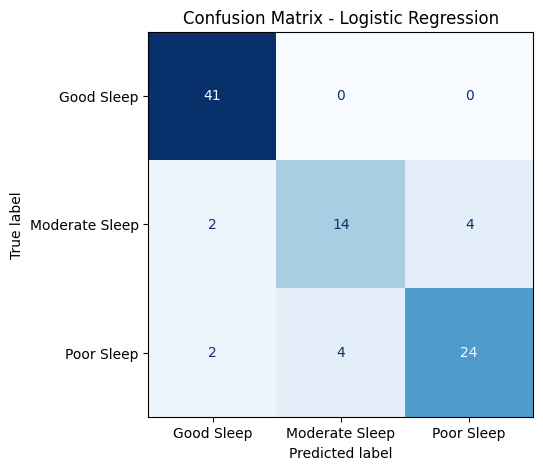

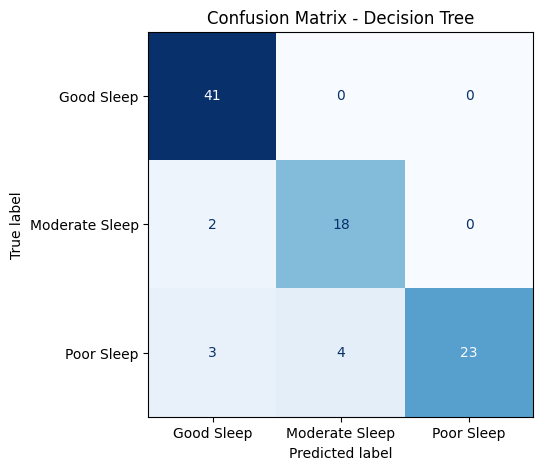

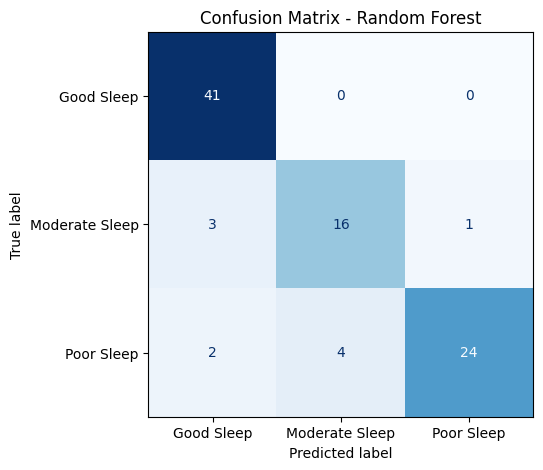

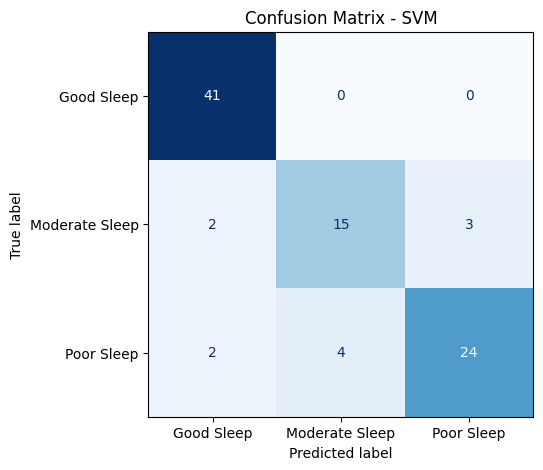

In [15]:
for model_name, (cm, labels) in conf_matrices.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.show()

## 11. Detailed classification reports

In [16]:
for model_name, report_df in reports.items():
    print("=" * 80)
    print(model_name)
    display(report_df.round(4))

Logistic Regression


,precision,recall,f1-score,support
Good Sleep,0.9111,1.0000,0.9535,41.0000
Moderate Sleep,0.7778,0.7000,0.7368,20.0000
Poor Sleep,0.8571,0.8000,0.8276,30.0000
accuracy,0.8681,0.8681,0.8681,0.8681
macro avg,0.8487,0.8333,0.8393,91.0000
weighted avg,0.8640,0.8681,0.8644,91.0000


Decision Tree


,precision,recall,f1-score,support
Good Sleep,0.8913,1.0000,0.9425,41.0000
Moderate Sleep,0.8182,0.9000,0.8571,20.0000
Poor Sleep,1.0000,0.7667,0.8679,30.0000
accuracy,0.9011,0.9011,0.9011,0.9011
macro avg,0.9032,0.8889,0.8892,91.0000
weighted avg,0.9111,0.9011,0.8992,91.0000


Random Forest


,precision,recall,f1-score,support
Good Sleep,0.8913,1.0000,0.9425,41.0000
Moderate Sleep,0.8000,0.8000,0.8000,20.0000
Poor Sleep,0.9600,0.8000,0.8727,30.0000
accuracy,0.8901,0.8901,0.8901,0.8901
macro avg,0.8838,0.8667,0.8718,91.0000
weighted avg,0.8939,0.8901,0.8882,91.0000


SVM


,precision,recall,f1-score,support
Good Sleep,0.9111,1.0000,0.9535,41.0000
Moderate Sleep,0.7895,0.7500,0.7692,20.0000
Poor Sleep,0.8889,0.8000,0.8421,30.0000
accuracy,0.8791,0.8791,0.8791,0.8791
macro avg,0.8632,0.8500,0.8549,91.0000
weighted avg,0.8771,0.8791,0.8763,91.0000


## 12. Select the best model

We select the model with the highest **test F1-score**.
If your instructor prefers another selection criterion, you can change it here.

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]

print("Best model selected:", best_model_name)
print("\nBest model parameters:")
best_row = results_df[results_df["Model"] == best_model_name].iloc[0]
print(best_row["Best Parameters"])

Best model selected: Decision Tree

Best model parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}


## 13. Feature importance / interpretability

The proposal asks for identifying the most influential lifestyle factors.

- If the best model is Random Forest, we use built-in feature importances.
- If it is Logistic Regression or linear SVM, we use coefficient magnitudes.
- If it is a non-linear SVM, feature importance is not directly available, so a note is shown.

,Feature,Importance
0,deep_sleep_percentage,0.477827
1,awakenings,0.413779
2,alcohol_consumption,0.047552
3,exercise_frequency,0.032605
4,rem_sleep_percentage,0.020824
5,age,0.007413
6,wakeup_time_2021-05-19 08:30:00,0.000000
7,wakeup_time_2021-05-21 07:30:00,0.000000
8,wakeup_time_2021-05-21 10:30:00,0.000000
9,wakeup_time_2021-05-24 08:30:00,0.000000


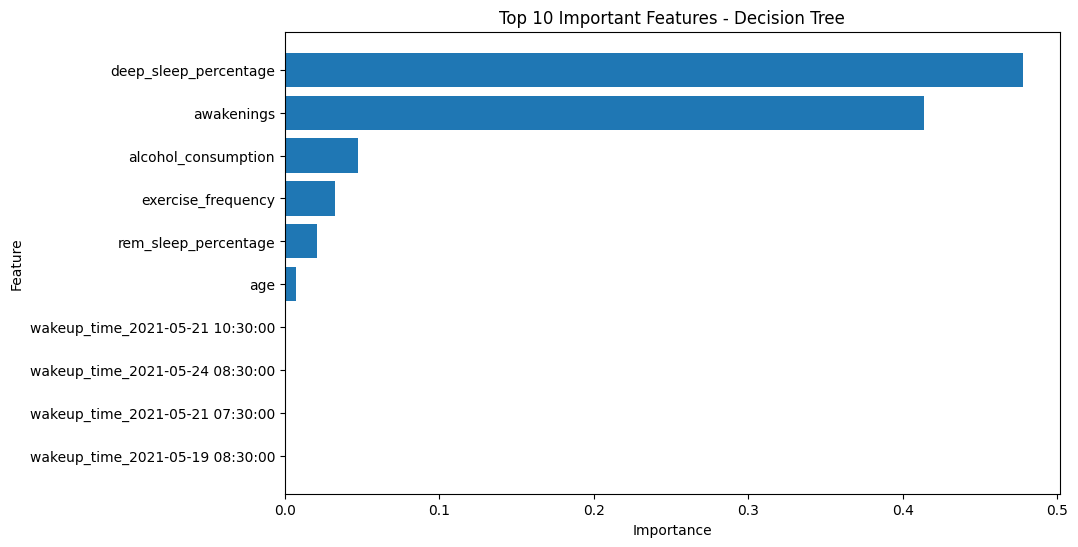

In [18]:
# Helper: get transformed feature names from the preprocessor
def get_feature_names_from_column_transformer(column_transformer):
    output_features = []
    for name, transformer, columns in column_transformer.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                try:
                    names = last_step.get_feature_names_out(columns)
                except:
                    names = columns
            else:
                names = columns
        else:
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    names = transformer.get_feature_names_out(columns)
                except:
                    names = columns
            else:
                names = columns
        output_features.extend(names)
    return output_features

preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]
feature_names = get_feature_names_from_column_transformer(preprocessor_fitted)

importance_df = None

if hasattr(classifier_fitted, "feature_importances_"):
    importances = classifier_fitted.feature_importances_
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

elif hasattr(classifier_fitted, "coef_"):
    coef = classifier_fitted.coef_
    if coef.ndim == 2:
        importances = np.mean(np.abs(coef), axis=0)
    else:
        importances = np.abs(coef)
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

if importance_df is not None:
    display(importance_df.head(15).reset_index(drop=True))

    plt.figure(figsize=(10, 6))
    top_n = importance_df.head(10).sort_values(by="Importance", ascending=True)
    plt.barh(top_n["Feature"], top_n["Importance"])
    plt.title(f"Top 10 Important Features - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print(f"Direct feature importance is not available for {best_model_name}.")
    print("If needed, permutation importance can be added.")

## 14. Automated performance analysis summary

This cell creates a ready-to-use paragraph for your report or presentation.

In [19]:
summary_lines = []

summary_lines.append(
    f"The project compared four supervised classification models: Logistic Regression, Decision Tree, Random Forest, and SVM."
)
summary_lines.append(
    f"Using GridSearchCV with 5-fold stratified cross-validation, the best-performing model was {best_model_name}."
)

best_metrics = results_df.iloc[0]
summary_lines.append(
    f"On the held-out test set, the selected model achieved an accuracy of {best_metrics['Test Accuracy']:.4f}, "
    f"precision of {best_metrics['Test Precision']:.4f}, recall of {best_metrics['Test Recall']:.4f}, "
    f"and F1-score of {best_metrics['Test F1-Score']:.4f}."
)
summary_lines.append(
    f"The confusion matrix shows how well the model distinguishes between Poor Sleep, Moderate Sleep, and Good Sleep classes."
)

if importance_df is not None:
    top_features = importance_df.head(5)["Feature"].tolist()
    summary_lines.append(
        "Feature analysis suggests that the most influential variables include: "
        + ", ".join(top_features) + "."
    )

summary_lines.append(
    "Overall, the model demonstrates the feasibility of predicting sleep quality from behavioral and lifestyle variables, "
    "which supports the objective of the SleepWise system."
)

performance_summary = " ".join(summary_lines)
print(performance_summary)

The project compared four supervised classification models: Logistic Regression, Decision Tree, Random Forest, and SVM. Using GridSearchCV with 5-fold stratified cross-validation, the best-performing model was Decision Tree. On the held-out test set, the selected model achieved an accuracy of 0.9011, precision of 0.9111, recall of 0.9011, and F1-score of 0.8992. The confusion matrix shows how well the model distinguishes between Poor Sleep, Moderate Sleep, and Good Sleep classes. Feature analysis suggests that the most influential variables include: deep_sleep_percentage, awakenings, alcohol_consumption, exercise_frequency, rem_sleep_percentage. Overall, the model demonstrates the feasibility of predicting sleep quality from behavioral and lifestyle variables, which supports the objective of the SleepWise system.


## 15. Save final artifacts

This section saves:
- model comparison results
- detailed classification reports
- top feature importance table

These files can support your report and presentation.

In [20]:
results_df.to_csv("model_comparison_results.csv", index=False)

# Save each classification report
for model_name, report_df in reports.items():
    safe_name = model_name.lower().replace(" ", "_")
    report_df.to_csv(f"{safe_name}_classification_report.csv")

if importance_df is not None:
    importance_df.to_csv("feature_importance.csv", index=False)

print("Artifacts saved successfully.")

Artifacts saved successfully.


## 16. Optional deployment-ready prediction helper

This small function can be reused later for a simple interface.
It takes a dictionary of user inputs and returns the predicted sleep class.

In [21]:
def predict_sleep_quality(input_dict, model=best_model):
    input_df = pd.DataFrame([input_dict])
    prediction = model.predict(input_df)[0]
    return prediction

# Example usage:
# sample_input = {
#     "age": 25,
#     "sleep_duration": 7.5,
#     "caffeine_consumption": 2,
#     "smoking_status": "No",
#     "alcohol_consumption": 1,
#     "exercise_frequency": 3,
#     "stress_level": 6
# }
# print(predict_sleep_quality(sample_input))

## 17. Final checklist for submission

Before submitting:
- Run all cells successfully
- Make sure the dataset path is correct
- Verify the output tables and confusion matrices
- Rename the notebook file with your actual group number
- Submit the `.ipynb` file